<a href="https://colab.research.google.com/github/HST0077/HYOTC/blob/main/IRmodelling_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bootstrapping Method**

In [1]:
# 3개월만기, 분기쿠폰 지급, zero coupon, 현재가 99.6의 쿠폰의 Yield
from sympy import symbols, exp, solve
R=symbols('R')
eq=99.6*exp(R*0.25)-100
R_0_25=solve(eq,R)[0]
R_0_25

0.0160320855901553

In [2]:
# 6개월만기, 반기쿠폰 지급, zero coupon, 현재가 99.0의 쿠폰의 Yield
from sympy import symbols, exp, solve
R=symbols('R')
eq=99.0*exp(R*0.5)-100
R_0_5=solve(eq,R)[0]
R_0_5

0.0201006717070029

In [3]:
# 1년 만기, 1년 쿠폰 지급, zero coupon, 현재가 97.8의 쿠폰의 Yield
from sympy import symbols, exp, solve
R=symbols('R')
eq=97.8*exp(R*1)-100
R_1_0=solve(eq,R)[0]
R_1_0

0.0222456089473197

In [4]:
# 만기 1.5년인 채권은 쿠폰이 4%, 6개월마다 쿠폰 지급, 현재가 102.5의 쿠폰의 Yield
from sympy import symbols, exp, solve
R=symbols('R')
eq=102.5-2*exp(-0.5*R_0_5)-2*exp(-1.0*R_1_0)-102*exp(-1.5*R)
R_1_5=solve(eq,R)[0]
R_1_5

0.0228444866046681

In [5]:
# 만기 2년, 쿠폰이 5%, 6개월마다 쿠폰 지급, 현재가 105의 쿠폰의 Yield
from sympy import symbols, exp, solve
R=symbols('R')
eq=105-2.5*exp(-0.5*R_0_5)-2.5*exp(-1.0*R_1_0)-2.5*exp(-1.5*R_1_5)-102.5*exp(-2*R)
R_2_0=solve(eq,R)[0]
R_2_0

0.0241637869533881

Calculated Spot Rates (Zero Rates):
0.25Y: 1.6032%
0.50Y: 2.0101%
1.00Y: 2.2246%
1.50Y: 2.2844%
2.00Y: 2.4164%



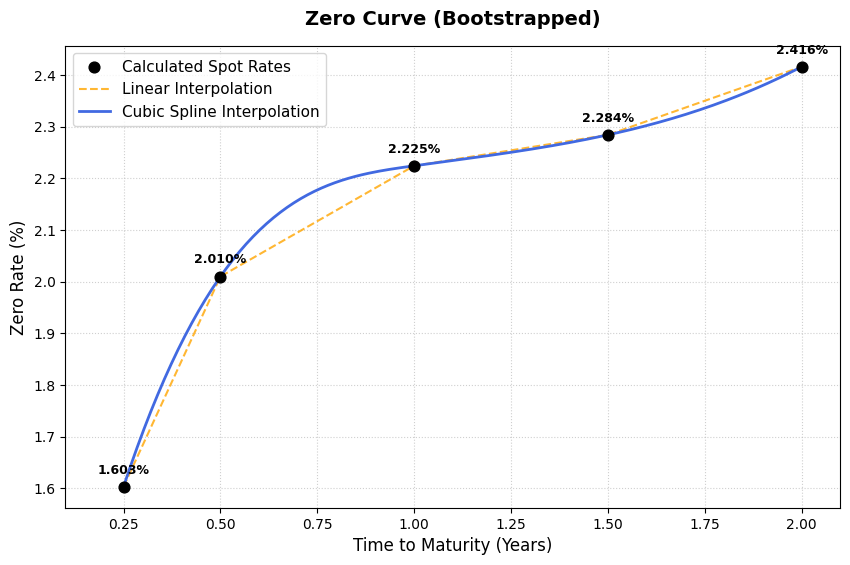

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline

# 1. 주어진 기초 데이터 입력 (연속복리 이자율 계산)
# 가격 공식: Price = Principal * exp(-R * T)  -->  R = -ln(Price/Principal) / T

# 0.25년 (만기 3개월 무이표채)
R_0_25 = -np.log(99.6 / 100) / 0.25

# 0.50년 (만기 6개월 무이표채)
R_0_50 = -np.log(99.0 / 100) / 0.50

# 1.00년 (만기 1년 무이표채)
R_1_00 = -np.log(97.8 / 100) / 1.00

print(f"Calculated Spot Rates (Zero Rates):")
print(f"0.25Y: {R_0_25*100:.4f}%")
print(f"0.50Y: {R_0_50*100:.4f}%")
print(f"1.00Y: {R_1_00*100:.4f}%")

# 1.50년 (쿠폰채, 6개월마다 쿠폰 2씩 지급, 현재가 102.5)
# 102.5 = 2*exp(-0.5*R_0_50) + 2*exp(-1.0*R_1_00) + 102*exp(-1.5*R_1_50)
# 위 방정식을 R_1_50에 대해 정리:
cash_flow_1_5 = 102.5 - 2*np.exp(-0.5*R_0_50) - 2*np.exp(-1.0*R_1_00)
R_1_50 = -np.log(cash_flow_1_5 / 102) / 1.50
print(f"1.50Y: {R_1_50*100:.4f}%")

# 2.00년 (쿠폰채, 6개월마다 쿠폰 2.5씩 지급, 현재가 105.0)
# 105.0 = 2.5*exp(-0.5*R_0_50) + 2.5*exp(-1.0*R_1_00) + 2.5*exp(-1.5*R_1_50) + 102.5*exp(-2.0*R_2_00)
cash_flow_2_0 = 105.0 - 2.5*np.exp(-0.5*R_0_50) - 2.5*np.exp(-1.0*R_1_00) - 2.5*np.exp(-1.5*R_1_50)
R_2_00 = -np.log(cash_flow_2_0 / 102.5) / 2.00
print(f"2.00Y: {R_2_00*100:.4f}%\n")

# --- 보간법(Interpolation) 및 그래프 그리기 ---

# 계산된 데이터 점 정의
tenors = np.array([0.25, 0.50, 1.00, 1.50, 2.00])
zero_rates = np.array([R_0_25, R_0_50, R_1_00, R_1_50, R_2_00]) * 100 # % 단위 전환

# 촘촘한 X축 데이터 생성 (0.25년부터 2.0년까지)
tenors_dense = np.linspace(0.25, 2.00, 200)

# 1) 선형 보간 (Linear Interpolation)
linear_interp = interp1d(tenors, zero_rates, kind='linear')
rates_linear = linear_interp(tenors_dense)

# 2) 3차 스플라인 보간 (Cubic Spline Interpolation) - 부드러운 곡선
cubic_spline = CubicSpline(tenors, zero_rates)
rates_cubic = cubic_spline(tenors_dense)

# 그래프 시각화
plt.figure(figsize=(10, 6))

# 데이터 점 표시
plt.scatter(tenors, zero_rates, color='black', zorder=5, s=60, label='Calculated Spot Rates')

# 보간선 그리기
plt.plot(tenors_dense, rates_linear, '--', label='Linear Interpolation', color='orange', alpha=0.8)
plt.plot(tenors_dense, rates_cubic, label='Cubic Spline Interpolation', color='royalblue', linewidth=2)

# 그래프 서식 설정
plt.title('Zero Curve (Bootstrapped)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time to Maturity (Years)', fontsize=12)
plt.ylabel('Zero Rate (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.xlim(0.1, 2.1)

# 데이터 점마다 라벨(y값) 달아주기
for x, y in zip(tenors, zero_rates):
    plt.text(x, y + 0.02, f'{y:.3f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.show()

In [28]:
# 1년과 2년 사이에 적용되는 선도금리를 구해보아라.
import numpy as np

# 앞의 부트스트래핑 과정에서 도출된 연속복리 이자율 (Zero Rate)
R_1_00 = -np.log(97.8 / 100) / 1.00   # 1년물 Zero Rate
print(f"1년물 Zero Rate (R1): {R_1_00*100:.4f}%")

# 2년물 이자율 복원을 위해 앞서 계산했던 1.5년물 값 재계산
R_0_50 = -np.log(99.0 / 100) / 0.50
cash_flow_1_5 = 102.5 - 2*np.exp(-0.5*R_0_50) - 2*np.exp(-1.0*R_1_00)
R_1_50 = -np.log(cash_flow_1_5 / 102) / 1.50

# 2년물 Zero Rate 계산
cash_flow_2_0 = 105.0 - 2.5*np.exp(-0.5*R_0_50) - 2.5*np.exp(-1.0*R_1_00) - 2.5*np.exp(-1.5*R_1_50)
R_2_00 = -np.log(cash_flow_2_0 / 102.5) / 2.00
print(f"2년물 Zero Rate (R2): {R_2_00*100:.4f}%")

# --- 1년에서 2년 사이의 선도금리 (Forward Rate) 계산 ---
T1 = 1.0
T2 = 2.0

# 연속복리 선도금리 공식 적용
F_1_2 = (R_2_00 * T2 - R_1_00 * T1) / (T2 - T1)

print("\n--- 결과 ---")
print(f"1년~2년 구간 선도금리(연속복리): {F_1_2 * 100:.4f}%")

1년물 Zero Rate (R1): 2.2246%
2년물 Zero Rate (R2): 2.4164%

--- 결과 ---
1년~2년 구간 선도금리(연속복리): 2.6082%


In [31]:
R_1_0

0.0222456089473197

In [36]:
1030454+22494-1045495

7453

# Short rate simulation

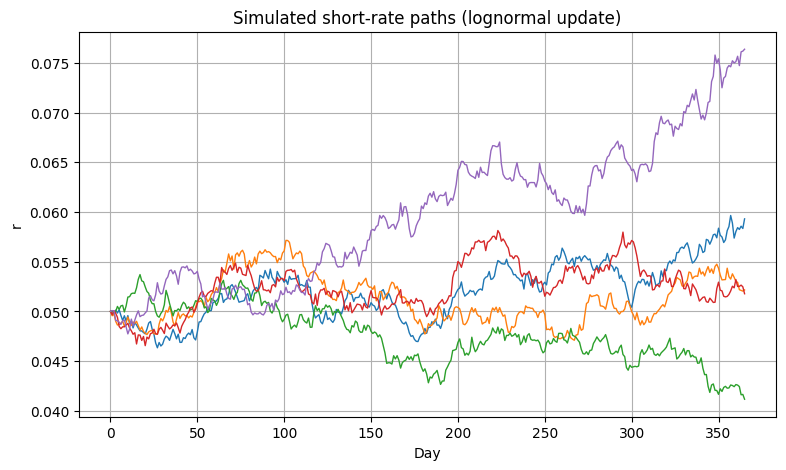

In [2]:
import numpy as np
import matplotlib.pyplot as plt

r0, sigma, n_days, n_paths, seed = 0.05, 0.2, 365, 1000, 111
rng = np.random.default_rng(seed)
dt = 1.0 / 365.0

Z = rng.standard_normal(size=(n_days, n_paths)) * np.sqrt(dt)
incr = sigma * Z - 0.5 * sigma**2 * dt  # (n_days, n_paths)

log_r = np.cumsum(incr, axis=0)
r = r0 * np.exp(log_r)

r = np.vstack([np.full((1, n_paths), r0), r])  # (n_days+1, n_paths)


# 처음 5개 경로만 그리기
plt.figure(figsize=(9, 5))
for i in range(5):
    plt.plot(r[:,i], linewidth=1)
plt.title("Simulated short-rate paths (lognormal update)")
plt.xlabel("Day")
plt.ylabel("r")
plt.grid(True)
plt.show()

# Black's Formula

In [2]:
def black76(F0: float, K: float, T: float, discT:float,
            r:float, sigma: float, callput='c'):
  import math
  from scipy.stats import norm

  sig_sqrtT = sigma * math.sqrt(T)
  d1 = (math.log(F0 / K) + 0.5 * sigma * sigma * T) / sig_sqrtT
  d2 = d1 - sig_sqrtT

  df = math.exp(-r * discT)

  if callput == 'c':
    price = df * (F0 * norm.cdf(d1) - K * norm.cdf(d2))
  elif callput == 'p':
    price = df * (K * norm.cdf(-d2) - F0 * norm.cdf(-d1))

  return price

In [3]:
F0 = 0.05
K = 0.045
T = 0.75
discT = 1
r = 0.05
sigma = 0.10

caplet=black76(F0, K, T, discT, r, sigma, 'c')
caplet

np.float64(0.004967877661826714)

In [4]:
caplet*1000000*0.25

np.float64(1241.9694154566785)

In [5]:
floorlet=black76(F0, K, T,discT, r, sigma, 'p')
floorlet*1000000*0.25

np.float64(52.93263483078449)

In [6]:
import math
import numpy as np

rng = np.random.default_rng(111)

# Z 생성 (antithetic variance reduction)
antithetic='True'
n_paths =10000

if antithetic:
    half = (n_paths + 1) // 2
    Z_half = rng.standard_normal(half)
    Z = np.concatenate([Z_half, -Z_half])[:n_paths]
else:
    Z = rng.standard_normal(n_paths)

# F_T 시뮬레이션 (lognormal)
drift = -0.5 * sigma * sigma * T
vol = sigma * math.sqrt(T)
FT = F0 * np.exp(drift + vol * Z)

payoff = np.maximum(FT - K, 0.0)
df = math.exp(-r * discT)
pv = df * payoff.mean()
pv

np.float64(0.0049527187117466)

In [5]:
def black76_MC(F0: float, K: float, T: float, discT:float,
               r:float, sigma: float, callput='c',n_paths=100000, antithetic='True',seed=111):
  import math
  import numpy as np

  rng = np.random.default_rng(seed)

  # Z 생성 (antithetic variance reduction)
  if antithetic:
      half = (n_paths + 1) // 2
      Z_half = rng.standard_normal(half)
      Z = np.concatenate([Z_half, -Z_half])[:n_paths]
  else:
      Z = rng.standard_normal(n_paths)

  # F_T 시뮬레이션 (lognormal)
  drift = -0.5 * sigma * sigma * T
  vol = sigma * math.sqrt(T)
  FT = F0 * np.exp(drift + vol * Z)

  # payoff
  if callput == "c":
      payoff = np.maximum(FT - K, 0.0)
  else:
      payoff = np.maximum(K - FT, 0.0)

  df = math.exp(-r * discT)
  pv = df * payoff.mean()

  return pv

In [6]:
black76_MC(F0, K, T, discT, r, sigma, 'c')

np.float64(0.004962967465053491)

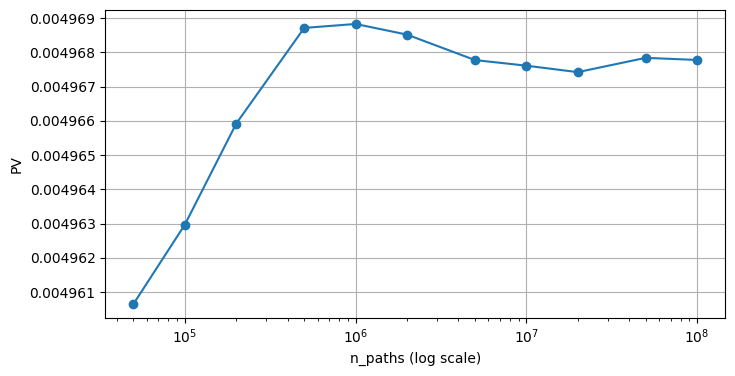

In [8]:
# 수렴성 보기
import numpy as np
import matplotlib.pyplot as plt

Ns = [50_000, 100_000, 200_000, 500_000,1000000, 2000000,5000000,10000000,20000000,50000000,100000000]
vals = []

for n in Ns:
    pv= black76_MC(F0, K, T, discT, r, sigma,callput='c',n_paths=n)
    vals.append(pv)

plt.figure(figsize=(8,4))
plt.plot(Ns, vals, marker='o')
plt.xscale('log')
plt.xlabel("n_paths (log scale)")
plt.ylabel("PV")
plt.grid(True)
plt.show()